In [1]:
from Bio import SeqIO
from collections import Counter
import pandas as pd 
import re
import requests
import json
import time
import glob
import pprint
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import pycountry 
import pycountry_convert as pc
pp = pprint.PrettyPrinter()
import numpy as np
from tabulate import tabulate
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
from matplotlib import cm
from shapely.geometry import Point, Polygon
import regex as re
import plotly.graph_objects as go
import os

import plotly.express as px

import scipy.stats
import statsmodels.formula.api as smf
#import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
import pandas.plotting as pd_plot
# Use tab20 colormap to manually select colors
colormap = cm.get_cmap('tab20')


C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_7484\316050140.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20')


In [2]:
%set_env folder = \\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\

env: folder=\\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\


In [3]:
path = %env folder

In [4]:
df_raw = pd.read_csv(path+R'\processed_data\extractivism_com3_type_time_iucn.csv', index_col = 0,dtype={'id_select': 'str'})

### 1. prepare data

In [45]:
df_pre = df_raw.copy().astype({'community':'str', 'marine':'int', 'crops': 'int', 'pathogens':'int'}).set_index(['id_select']).rename(columns = {'Viruses':'viruses', 'Eukaryota':'eukaryota', 'Bacteria':'bacteria', 'Archaea':'archaea'})

In [71]:
#dichotomize semantic categories
df = df_pre.join(pd.get_dummies(df_pre['community'], dtype=float,prefix='community')).drop(columns = ['community']).rename(columns = { 'community_0.0':'public_health','community_1.0':'biotechnology', 'community_2.0':'basic_research','iucn_cat_binary': 'iucn_threatened'}) 

In [65]:
df

,extractivism_g77_oecd_1,extractivism_g77_brics_1,extractivism_oecd_brics_1,extractivism_oecd_g77_1,extractivism_brics_g77_1,extractivism_brics_oecd_1,extractivism_g77_oecd_2,extractivism_g77_brics_2,extractivism_oecd_brics_2,extractivism_oecd_g77_2,...,crops,year_published,after_nagoya,megadiv,megadiv_g77,megadiv_brics,iucn_threatened,public_health,biotechnology,basic_research
id_select,,,,,,,,,,,,,,,,,,,,,
10.1002/jpln.201100382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2012,0.0,0,0,0,0,0.0,1.0,0.0
10.1002/jsfa.8281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2017,1.0,0,0,0,0,0.0,1.0,0.0
10.1002/mrd.22210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2013,0.0,0,0,0,0,0.0,1.0,0.0
10.1006/bojl.2001.0485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2001,0.0,0,0,0,0,0.0,0.0,1.0
10.1007/s001220050005,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,...,0,2000,0.0,0,0,0,0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pmc93007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2001,0.0,0,0,0,0,0.0,1.0,0.0
pmc93245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2001,0.0,0,0,0,0,0.0,1.0,0.0
pmc93301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2001,0.0,0,0,0,0,0.0,1.0,0.0


In [51]:
#construct general authorship type variable
no_local_authors = list(df.index[(df['extractivism_g77_oecd_2'] == 1) | 
        (df['extractivism_g77_brics_2'] == 1) | 
        (df['extractivism_brics_oecd_2'] == 1) | 
        (df['extractivism_brics_g77_2'] == 1) | 
        (df['extractivism_oecd_brics_2'] == 1) | 
        (df['extractivism_oecd_g77_2'] == 1)])

foreign_lead = list(df.index[(df['extractivism_g77_oecd_1'] == 1) | 
        (df['extractivism_g77_brics_1'] == 1) | 
        (df['extractivism_brics_oecd_1'] == 1) | 
        (df['extractivism_brics_g77_1'] == 1) | 
        (df['extractivism_oecd_brics_1'] == 1) | 
        (df['extractivism_oecd_g77_1'] == 1)])

any_int_sourcing = list(df.index[(df['g77_oecd'] == 1) | 
        (df['g77_brics'] == 1) | 
        (df['oecd_brics'] == 1) | 
        (df['oecd_g77'] == 1) | 
        (df['brics_g77'] == 1) | 
        (df['brics_oecd'] == 1)])


In [59]:
no_local_authors_var = []
foreign_lead_var = []
sourcing = []
for id_select in df.index.tolist():
    source = 0
    foreign_l = 0
    no_local = 0
    
    if id_select in any_int_sourcing:
        source = 1
        if id_select in no_local_authors: 
            no_local = 1
        else:
            no_local = 0
        if id_select in foreign_lead: 
            foreign_l = 1
        else:
            foreign_l = 0
    else:
        source = 0

    sourcing.append(source)
    foreign_lead_var.append(foreign_l)
    no_local_authors_var.append(no_local)


df['foreign_lead'] = foreign_lead_var
df['no_local_authors'] = no_local_authors_var
df['sourcing_international'] = sourcing

In [87]:
sourcing_local_lead = df[(df['sourcing_international'] == 1) & (df['foreign_lead'] == 0) & (df['no_local_authors'] == 0)].index.to_list()
sourcing_domestic = df[df['sourcing_international'] == 0].index.to_list()
source_local_lead = []
source_domestic = []

for id_select in df.index.tolist():
    source_local_lead_ph = 0
    source_domestic_ph = 0
    if id_select in sourcing_local_lead:
        source_local_lead_ph = 1
    else:
        source_local_lead_ph = 0

    if id_select in sourcing_domestic: 
        source_domestic_ph = 1
    else: 
        source_domestic_ph = 0

    source_local_lead.append(source_local_lead_ph)
    source_domestic.append(source_domestic_ph)
    
df['local_lead'] = source_local_lead
df['sourcing_domestic'] = source_domestic

In [103]:
df.to_csv(path+r'\processed_data\resubmission_analysis.csv')

In [7]:
df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)

C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_7484\1384640488.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)


In [45]:
df_vis_table = df.rename(columns = {'no_local_authors': 'International DSI sourcing: Without local authors',
                              'foreign_lead': 'International DSI sourcing: Foreign lead authors',
                                'sourcing_domestic': 'Exclusively domestic DSI sourcing', 
                            'sourcing_international': 'International DSI sourcing',
                              'local_lead': 'International DSI sourcing: At least one local lead author',
                    'extractivism_g77_oecd_1':'G77 -> OECD foreign lead authors', 
                   'extractivism_g77_brics_1':'G77 -> BRICS foreign lead authors',
                   'extractivism_oecd_brics_1':'OECD -> BRICS foreign lead authors',
                   'extractivism_oecd_g77_1':'OECD -> G77 foreign lead authors', 
                   'extractivism_brics_g77_1': 'BRICS -> G77 foreign lead authors',
                    'extractivism_brics_oecd_1': 'BRICS -> OECD foreign lead authors',
                    'extractivism_g77_oecd_2':'G77 -> OECD without local authors', 
                   'extractivism_g77_brics_2':'G77 -> BRICS without local authors',
                   'extractivism_oecd_brics_2':'OECD -> BRICS without local authors',
                   'extractivism_oecd_g77_2':'OECD -> G77 without local authors', 
                   'extractivism_brics_g77_2': 'BRICS -> G77 without local authors',
                    'extractivism_brics_oecd_2': 'BRICS -> OECD without local authors',
                     'g77_oecd': 'G77 -> OECD',
                       'g77_brics': 'G77 -> BRICS', 
                        'oecd_brics': 'OECD -> BRICS', 
                        'oecd_g77': 'OECD -> G77', 
                        'brics_g77': 'BRICS -> G77', 
                        'brics_oecd': 'BRICS -> OECD',
                              
                    'public_health':'Public health',
                   'biotechnology':'Biotechnology', 
                   'basic_research':'Basic research', 
                   'iucn_threatened': 'IUCN threatened species',
                   'eukaryota':'Eukaryota',
 'bacteria':'Bacteria',
 'archaea':'Archaea',
 'viruses':'Viruses',
 'marine':'Marine',
 'pathogens': 'Pathogens',
 'crops':'Crops',
 'year_published':'Publication year',
 'after_nagoya':'After Nagoya',
 'megadiv':'Megabiodiverse',
    'megadiv_brics':'Megabiodiverse (BRICS)',
    'megadiv_g77':'Megabiodiverse (G77)'
    
                              
                             })

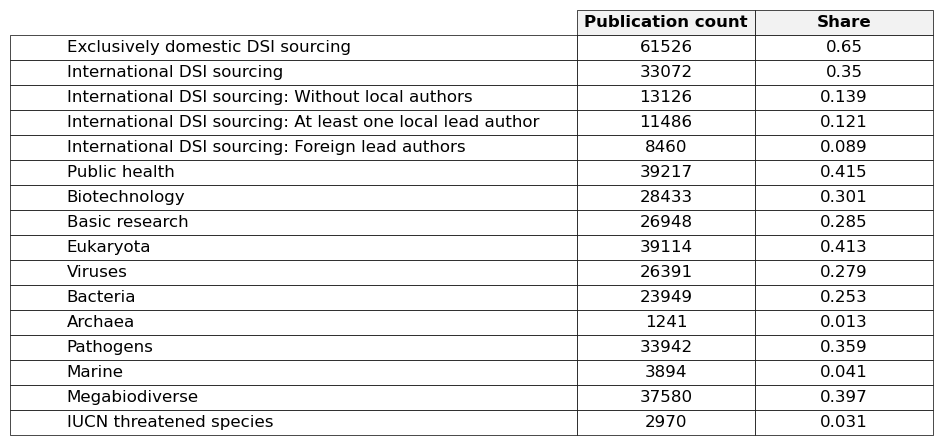

In [47]:
df_var_table_pred = df_vis_table[[
                                'Exclusively domestic DSI sourcing', 
                             'International DSI sourcing',
                            'International DSI sourcing: Without local authors',
                             'International DSI sourcing: At least one local lead author',
    'International DSI sourcing: Foreign lead authors',
    'Public health',
 'Biotechnology',
 'Basic research',
 'Eukaryota',
    'Viruses',
 'Bacteria',
 'Archaea',
    'Pathogens',
 'Marine',
    'Megabiodiverse',
                            
 'IUCN threatened species'
                                   
 

 ]].describe().loc[['mean']].transpose().reset_index().rename(columns = {'mean':'Share','index':'Predictor'})
                       
df_var_table_pred['Publication count'] = [str(x)[:-2] for x in df_vis_table[[
    'Exclusively domestic DSI sourcing', 
                             'International DSI sourcing',
                            'International DSI sourcing: Without local authors',
                             'International DSI sourcing: At least one local lead author',
    'International DSI sourcing: Foreign lead authors',
    'Public health',
 'Biotechnology',
 'Basic research',
 'Eukaryota',
'Viruses',
 'Bacteria',
 'Archaea',
 'Pathogens',
     'Marine',
    'Megabiodiverse',
                            
 'IUCN threatened species'
 

 ]].sum()]

# Create a figure without axes
fig = plt.figure(figsize=(2, 4))
ax = fig.add_subplot(111)

# Hide the axes to focus only on the table
ax.axis("off")

# Add the table directly to the figure
table = plt.table(
    cellText=df_var_table_pred[['Publication count', 'Share']].round(3).values,  # Table data as a 2D array
    colLabels=df_var_table_pred[[ 'Publication count', 'Share']].columns,        # Column headers
    rowLabels=df_var_table_pred[['Predictor', 'Publication count', 'Share']]['Predictor'],          # Row labels
    cellLoc="center",
    loc="center"
)

# Formatting the table
table.auto_set_font_size(False)
table.set_fontsize(12)  # Adjust font size
table.scale(2.3, 1.5)   # Scale table for better visibility

# Customize borders and header formatting
for key, cell in table.get_celld().items():
    cell.set_linewidth(0.5)  # Border width
    cell.set_edgecolor("black")  # Set border color
    if key[0] == 0:  # Header row
        cell.set_text_props(weight="bold")  # Bold headers
        cell.set_facecolor("#f2f2f2")  # Light gray background for headers

# Save the centered table
plt.savefig(path + R"plots/variable_share_variables_new.png", dpi=300, bbox_inches="tight")  # Tight crop
plt.show()


In [48]:
import pandas as pd
from tabulate import tabulate



# Convert the table to a nicely formatted text table without index
formatted_table = tabulate(df_var_table_pred, headers='keys', tablefmt='fancy_grid', showindex=False)
print(formatted_table)


╒════════════════════════════════════════════════════════════╤═══════════╤═════════════════════╕
│ Predictor                                                  │     Share │   Publication count │
╞════════════════════════════════════════════════════════════╪═══════════╪═════════════════════╡
│ Exclusively domestic DSI sourcing                          │ 0.650394  │               61526 │
├────────────────────────────────────────────────────────────┼───────────┼─────────────────────┤
│ International DSI sourcing                                 │ 0.349606  │               33072 │
├────────────────────────────────────────────────────────────┼───────────┼─────────────────────┤
│ International DSI sourcing: Without local authors          │ 0.138756  │               13126 │
├────────────────────────────────────────────────────────────┼───────────┼─────────────────────┤
│ International DSI sourcing: At least one local lead author │ 0.121419  │               11486 │
├─────────────────────────────

### 2. Flow plot

In [9]:
#df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)

C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_28476\1384640488.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)


In [169]:
df_vis = df.rename(columns = {'no_local_authors': 'International DSI sourcing: Without local authors',
                              'foreign_lead': 'International DSI sourcing: Foreign lead authors',
                            'sourcing_international': 'International DSI sourcing',
                              'sourcing_domestic': 'Domestic DSI sourcing',
                              'local_lead': 'International DSI sourcing: At least one local lead author',
                    'extractivism_g77_oecd_1':'G77 -> OECD foreign lead authors', 
                   'extractivism_g77_brics_1':'G77 -> BRICS foreign lead authors',
                   'extractivism_oecd_brics_1':'OECD -> BRICS foreign lead authors',
                   'extractivism_oecd_g77_1':'OECD -> G77 foreign lead authors', 
                   'extractivism_brics_g77_1': 'BRICS -> G77 foreign lead authors',
                    'extractivism_brics_oecd_1': 'BRICS -> OECD foreign lead authors',
                    'extractivism_g77_oecd_2':'G77 -> OECD without local authors', 
                   'extractivism_g77_brics_2':'G77 -> BRICS without local authors',
                   'extractivism_oecd_brics_2':'OECD -> BRICS without local authors',
                   'extractivism_oecd_g77_2':'OECD -> G77 without local authors', 
                   'extractivism_brics_g77_2': 'BRICS -> G77 without local authors',
                    'extractivism_brics_oecd_2': 'BRICS -> OECD without local authors',
                     'g77_oecd': 'G77 -> OECD',
                       'g77_brics': 'G77 -> BRICS', 
                        'oecd_brics': 'OECD -> BRICS', 
                        'oecd_g77': 'OECD -> G77', 
                        'brics_g77': 'BRICS -> G77', 
                        'brics_oecd': 'BRICS -> OECD',
                              
                    'public_health':'Public health',
                   'biotechnology':'Biotechnology', 
                   'basic_research':'Basic research', 
                   'iucn_threatened': 'IUCN threatened species',
                   'eukaryota':'Eukaryota',
 'bacteria':'Bacteria',
 'archaea':'Archaea',
 'viruses':'Viruses',
 'marine':'Marine',
 'pathogens': 'Pathogens',
 'crops':'Crops',
 'year_published':'Publication year',
 'after_nagoya':'After Nagoya',
 'megadiv':'Megabiodiverse',
    'megadiv_brics':'Megabiodiverse (BRICS)',
    'megadiv_g77':'Megabiodiverse (G77)'
    
                              
                             })

In [59]:
df_var_table_dep = df_vis[[
    'International DSI sourcing',
    'G77 -> OECD', 'G77 -> BRICS', 'OECD -> BRICS', 'OECD -> G77',
       'BRICS -> G77', 'BRICS -> OECD'

]].sum().reset_index().rename(columns = {0:'Publications'})

df_var_table_dep['Publications without local authors'] = [int(x) for x in list(df_vis[[
    'International DSI sourcing: Without local authors',
    'G77 -> OECD without local authors',
    'G77 -> BRICS without local authors',
     'OECD -> BRICS without local authors',
     'OECD -> G77 without local authors',
    'BRICS -> G77 without local authors',
    'BRICS -> OECD without local authors'
 ]].sum())]

df_var_table_dep['Share of publications without local authors'] = df_var_table_dep['Publications without local authors']/df_var_table_dep['Publications']

In [63]:
df_var_table_dep

,index,Publications,Publications without local authors,Share of publications without local authors
0,International DSI sourcing,33072,13126,0.396892
1,G77 -> OECD,18870,8631,0.457393
2,G77 -> BRICS,3619,799,0.220779
3,OECD -> BRICS,4175,893,0.213892
4,OECD -> G77,2993,261,0.087203
5,BRICS -> G77,2232,256,0.114695
6,BRICS -> OECD,12861,4929,0.383252


C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_21052\1125151082.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')


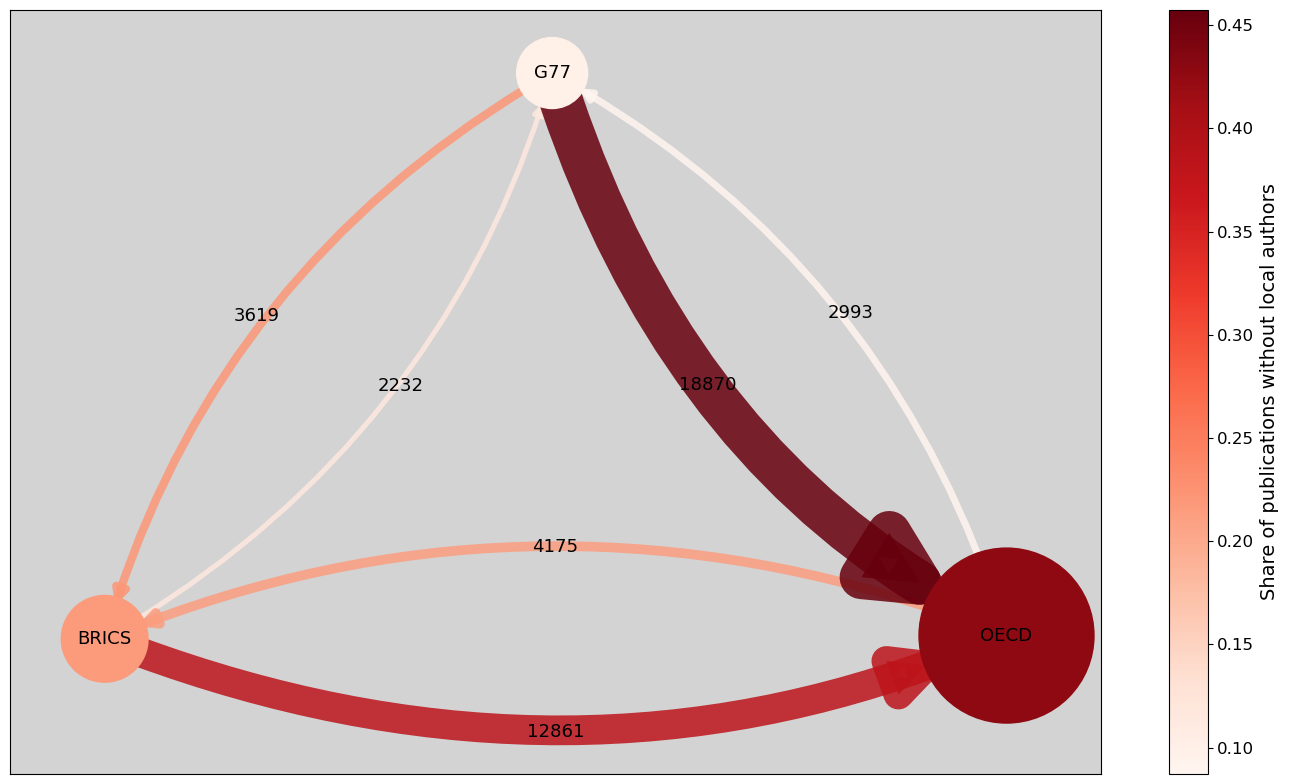

In [85]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm

# Create the DataFrame
data = {
    "Source": df_var_table_dep['index'].to_list()[1:],
    "Share of publications without local authors": df_var_table_dep['Share of publications without local authors'].to_list()[1:],
    "Publication count": df_var_table_dep['Publications'].to_list()[1:]
}
df_flows = pd.DataFrame(data)

# Extract source and target nodes from 'Extractivism type'
df_flows[['Source', 'Target']] = df_flows['Source'].str.extract(r'(\w+) -> (\w+)')
# Create a MultiDiGraph
G = nx.MultiDiGraph()

# Add edges with weights (publication count or share)
for _, row in df_flows.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Publication count'], share=row['Share of publications without local authors'])

# Normalize the 'share' variable for color coding
shares = [data['share'] for _, _, _, data in G.edges(data=True, keys=True)]
norm = plt.Normalize(vmin=min(shares), vmax=max(shares))
cmap = cm.get_cmap('Reds')

# Calculate node sizes based on incoming edge weights
node_sizes = {}
node_colors = {}  # To store node color based on weighted incoming shares
for node in G.nodes():
    incoming_edges = G.in_edges(node, data=True)  # Get incoming edges for the node
    
    # Calculate total Publication count and weighted average Share for incoming edges
    total_publication_count = sum(edge_data['weight'] for _, _, edge_data in incoming_edges)
    weighted_share_sum = sum(edge_data['share'] * edge_data['weight'] for _, _, edge_data in incoming_edges)
    
    # Handle case with no incoming edges
    if total_publication_count > 0:
        weighted_share = weighted_share_sum / total_publication_count
    else:
        weighted_share = 0  # No incoming edges
    
    # Set node size and color
    node_sizes[node] = total_publication_count / 2  # Scale node sizes
    node_colors[node] = cmap(norm(weighted_share))  # Map weighted share to color

# Calculate node radii from sizes (to dynamically adjust edge margins)
node_radii = {node: (size ** 0.3) / 0.6 for node, size in node_sizes.items()}

# Draw the MultiDiGraph with curved edges
fig, ax = plt.subplots(figsize=(14, 8))


# Position nodes using a spring layout
pos = nx.spring_layout(G, seed=120)

# Draw nodes with scaled sizes and colors
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[node_sizes[node] for node in G.nodes()],
    node_color=[node_colors[node] for node in G.nodes()],
    ax=ax
)

# Dictionary to store edge colors
edge_colors_extr2 = {}

# Sort edges by 'weight' or 'share' to control draw order (foreground/background)
sorted_edges = sorted(G.edges(data=True, keys=True), key=lambda edge: edge[3]['share'], reverse=False)

# Draw edges with dynamic margins and enhanced arrow styles
for u, v, key, data in sorted_edges:  # Use sorted edges
    # Compute the direction of the curve
    connectionstyle = 'arc3,rad=0.2' if key % 2 == 0 else 'arc3,rad=-0.2'  # Alternate curves

    # Edge color and width based on share and weight
    edge_color = cmap(norm(data['share']))
    edge_width = data['weight'] / 600  # Increased edge thickness

    # Store the color in the dictionary
    edge_colors_extr2[(u, v, key)] = edge_color

    # Dynamically scale arrow size based on edge thickness
    arrow_size = max(15, edge_width * 3)  # Scale arrow size with a minimum value

    # Dynamic margins based on node sizes
    source_margin = node_radii.get(u, 0)*1.25  # Margin for the source node
    target_margin = node_radii.get(v, 0)*1.25  # Margin for the target node

    # Draw edges with adjusted margins and arrow styles
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        width=edge_width,
        alpha=0.85,
        edge_color=[edge_color],
        connectionstyle=connectionstyle,
        min_source_margin=source_margin,  # Dynamic source margin
        min_target_margin=target_margin,  # Dynamic target margin
        arrowstyle='-|>',  # Enhanced arrow style
        arrowsize=arrow_size,  # Dynamically scaled arrow size
        ax=ax
    )

# Add edge labels for each direction with distinct offsets
for u, v, key, data in G.edges(data=True, keys=True):
    # Compute midpoints for edge labels
    mid_x = (pos[u][0] + pos[v][0]) / 2
    mid_y = (pos[u][1] + pos[v][1]) / 2

    # Apply offset to distinguish labels
    if u == 'BRICS' and v == 'OECD':
        offset_x = (pos[v][1] - pos[u][1]) * 0.14  # networkOffset perpendicular to edge
        offset_y = (pos[u][0] - pos[v][0]) * 0.14  # Offset perpendicular to edge
    elif u == 'OECD' and v == 'BRICS':
        offset_x = (pos[v][1] - pos[u][1]) * 0.12  # networkOffset perpendicular to edge
        offset_y = (pos[u][0] - pos[v][0]) * 0.12  # Offset perpendicular to edge
    else:   
        offset_x = (pos[v][1] - pos[u][1]) * 0.1  # networkOffset perpendicular to edge
        offset_y = (pos[u][0] - pos[v][0]) * 0.1  # Offset perpendicular to edge

    # Adjust offset direction based on the key (to avoid overlap)
    if key % 2 == 0:
        label_x = mid_x + offset_x
        label_y = mid_y + offset_y
    else:
        label_x = mid_x - offset_x
        label_y = mid_y - offset_y

    # Draw the label
    label = f"{data['weight']}"  # Use the publication count as the label
    plt.text(label_x, label_y, label, fontsize=13, color="black", ha="center")

# Add labels for nodes
nx.draw_networkx_labels(G, pos, font_size=13, font_color='black', ax=ax)

# Add colorbar for the 'share' variable
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)  # Tie colorbar to the current axis
cbar.set_label('Share of publications without local authors', fontsize=14)
ax.set_facecolor('lightgrey')
# Add title and show plot
#plt.title("Multi-Directional Network with Node Colors Based on Incoming Shares", fontsize=16)
plt.tight_layout()
plt.savefig(path+R"plots/multi_directional_graph_no_local_authors_reds_new.png", dpi=300, bbox_inches="tight")
plt.savefig(path+R"plots/multi_directional_graph_no_local_authors_reds_new.pdf", dpi=300, bbox_inches="tight")
plt.show()
   

### 3. Timeline

#### Main versions

In [171]:
#prepare visualizations
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import matplotlib.pyplot as plt
import matplotlib.cm as cm

#relable the extractivisms for vis
dep_var_vis_dict = {'International DSI sourcing': 'Both types', 
                    'International DSI sourcing: Without local authors': 'Without local authors', 
                    'International DSI sourcing: Foreign lead authors':'Foreign lead authors',
                    'International DSI sourcing: At least one local lead author': 'At least one local lead author'                    
                   }


 #       'International DSI sourcing: At least one local lead author': 'Collaboration',
  #      'International DSI sourcing: Foreign lead authors': 'Collaboration',
 #  'International DSI sourcing: Without local authors': 'Without local authors',
  #  'G77 -> OECD foreign lead authors': 'G77 -> OECD (foreign leads)',
  #  'G77 -> BRICS foreign lead authors': 'G77 -> BRICS (foreign leads)',
  #   'OECD -> BRICS foreign lead authors': 'OECD -> BRICS (foreign leads)',
  #  'OECD -> G77 foreign lead authors': 'OECD -> G77 (foreign leads)',
  # 'BRICS -> G77 foreign lead authors': 'BRICS -> G77 (foreign leads)',
   # 'BRICS -> OECD foreign lead authors': 'BRICS -> OECD (foreign leads)',
  #  'G77 -> OECD without local authors': 'G77 -> OECD',
  #  'G77 -> BRICS without local authors': 'G77 -> BRICS',
  #   'OECD -> BRICS without local authors': 'OECD -> BRICS',
 #   'OECD -> G77 without local authors': 'OECD -> G77',
  #  'BRICS -> G77 without local authors': 'BRICS -> G77',
  #  'BRICS -> OECD without local authors': 'BRICS -> OECD'}


# Fetch the color for a specific edge
color_g77_oecd_extr2 = edge_colors_extr2.get(('G77', 'OECD', 0), colormap(0))
cmap_blues = cm.get_cmap('Blues')
color_sourcing = cmap_blues(250)

# Define custom colors for each variable using tab20
colors = {
    'G77 -> OECD': color_g77_oecd_extr2,  # First color from tab20
    'G77 -> OECD (foreign leads)': colormap(0),
    'BRICS -> OECD': edge_colors_extr2.get(('BRICS', 'OECD', 0), colormap(0)) ,  # Second color
    'BRICS -> OECD (foreign leads)': edge_colors_extr2.get(('BRICS', 'OECD', 0), colormap(0)),
    'G77 -> BRICS': edge_colors_extr2.get(('G77', 'BRICS', 0), colormap(0)),  # Third color
    'G77 -> BRICS (foreign leads)': colormap(0),  # Sixth color
    'Without local authors': color_g77_oecd_extr2,
    'At least one local lead author': cmap_blues(250),
    'Foreign lead authors': colormap(3),
    'Collaborative': cmap_blues(250),
    'Both types':colormap(14),
    'All types': colormap(14)
    
}

# Define linestyles for each variable
linestyles = {
    'G77 -> OECD': ':',  
    'G77 -> OECD (foreign leads)': '-',  
    'BRICS -> OECD': ':',  
    'BRICS -> OECD (foreign leads)': '-',  
    'G77 -> BRICS': ':',  
    'G77 -> BRICS (foreign leads)': '-',    
    'At least one local lead author': ':', 
        'Foreign lead authors': ':',
    'Without local authors': ':',
    'International DSI sourcing': ':',
    'Both types': ':',
    'All types': ':',
    'Collaborative': ':'  
}

# Grouping and plotting the data
df_vis_timeline= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][df_vis['Publication year'] >= 2000].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline['Collaborative'] = df_vis_timeline['At least one local lead author'] + df_vis_timeline['Foreign lead authors']   

C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_21052\3522018393.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blues = cm.get_cmap('Blues')


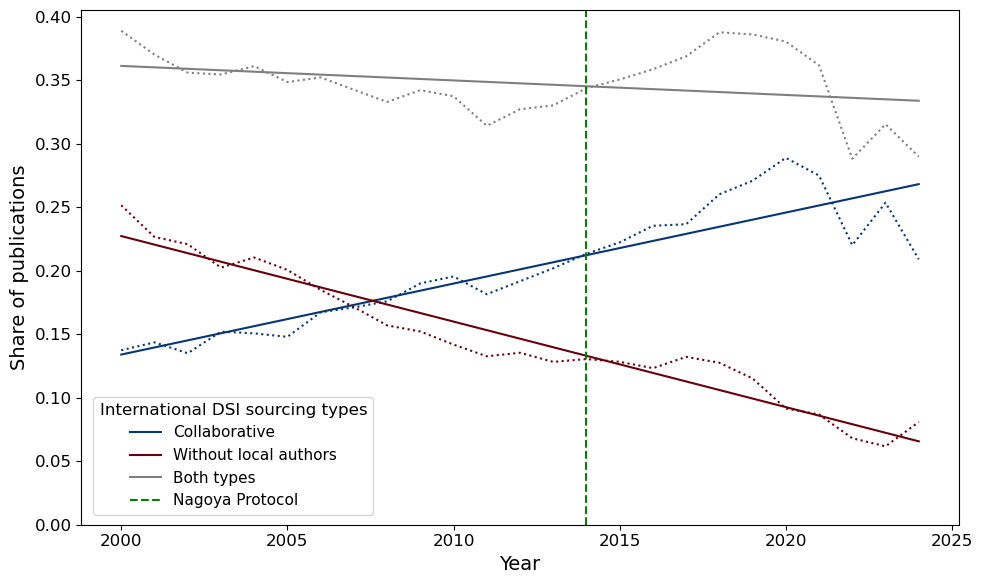

In [77]:
#main graph
#define graph version
df_vis_timeline_main = df_vis_timeline[['Collaborative','Without local authors', 'Both types']]
df_vis_timeline_version = df_vis_timeline_main


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles 
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes lines from the legend


# Fit and plot linear projections 
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_main.pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_main.png")
# Show the plot
plt.show()


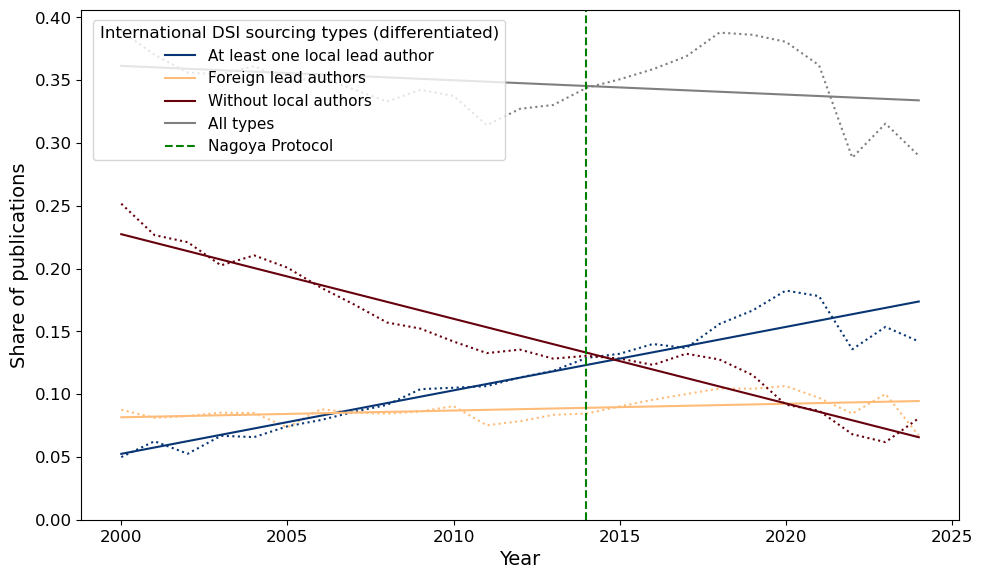

In [118]:
#full version 
#define graph version
df_vis_timeline_full = df_vis_timeline[['At least one local lead author', 'Foreign lead authors', 'Without local authors', 'Both types']].rename(columns = {'Both types':'All types'})
df_vis_timeline_version = df_vis_timeline_full

# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (differentiated)", fontsize = 11, bbox_to_anchor=(0.005, 0.69)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_full.pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_full.png")
# Show the plot
plt.show()


#### Variable-specific versions

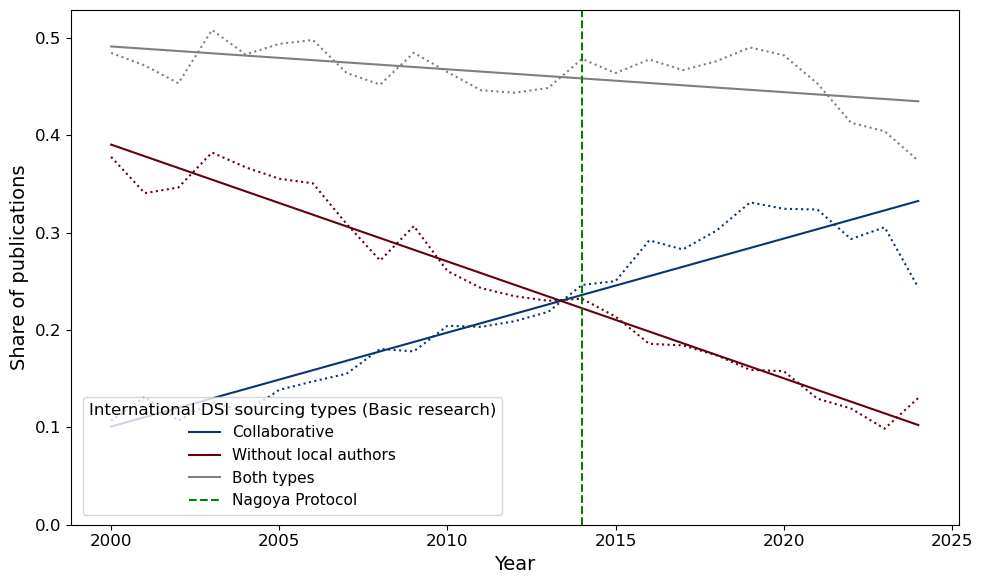

In [101]:
#define graph version
subtype = 'Basic research'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


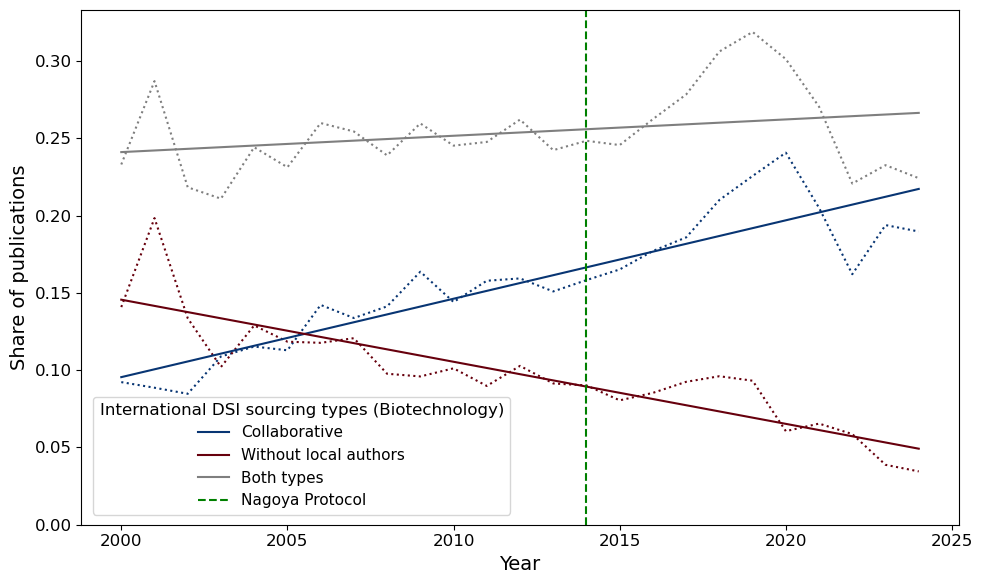

In [103]:
#define graph version
subtype = 'Biotechnology'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


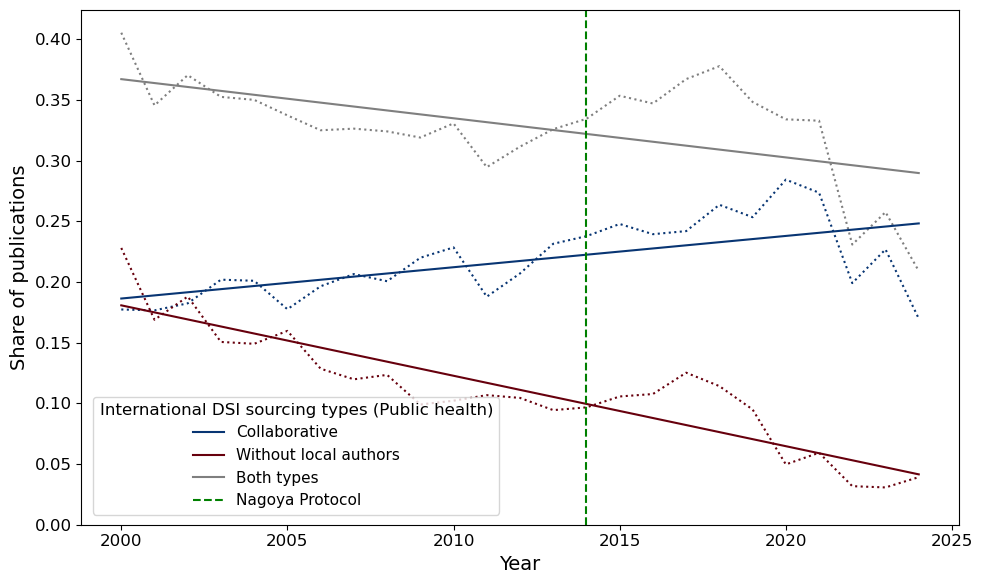

In [173]:
#define graph version
subtype = 'Public health'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


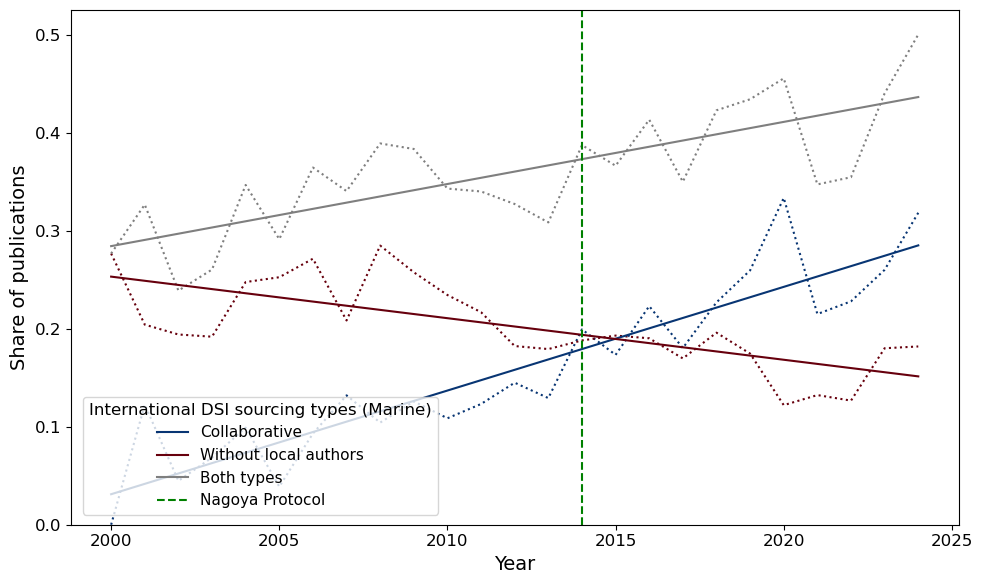

In [110]:
#define graph version
subtype = 'Marine'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


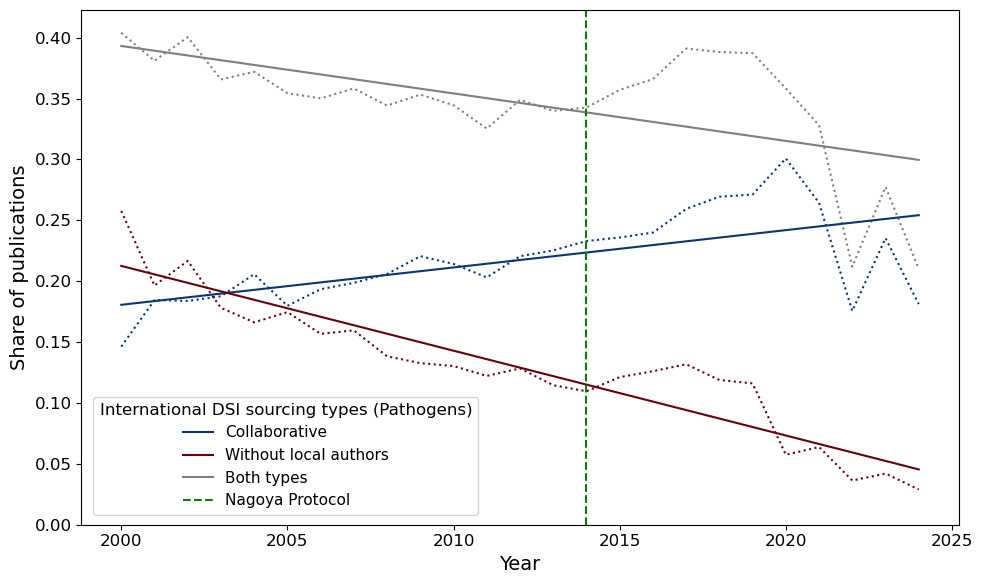

In [112]:
#define graph version
subtype = 'Pathogens'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


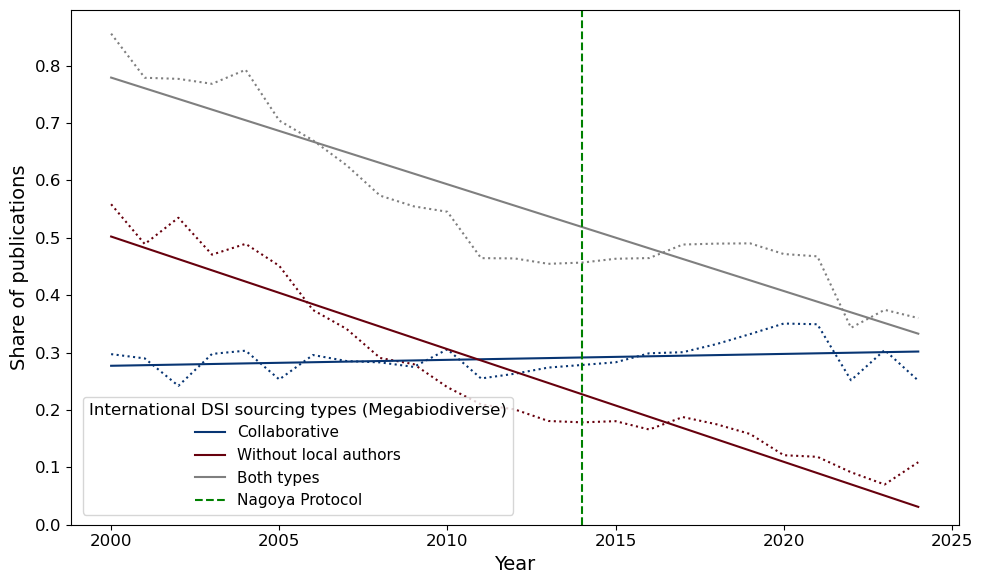

In [114]:
#define graph version
subtype = 'Megabiodiverse'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


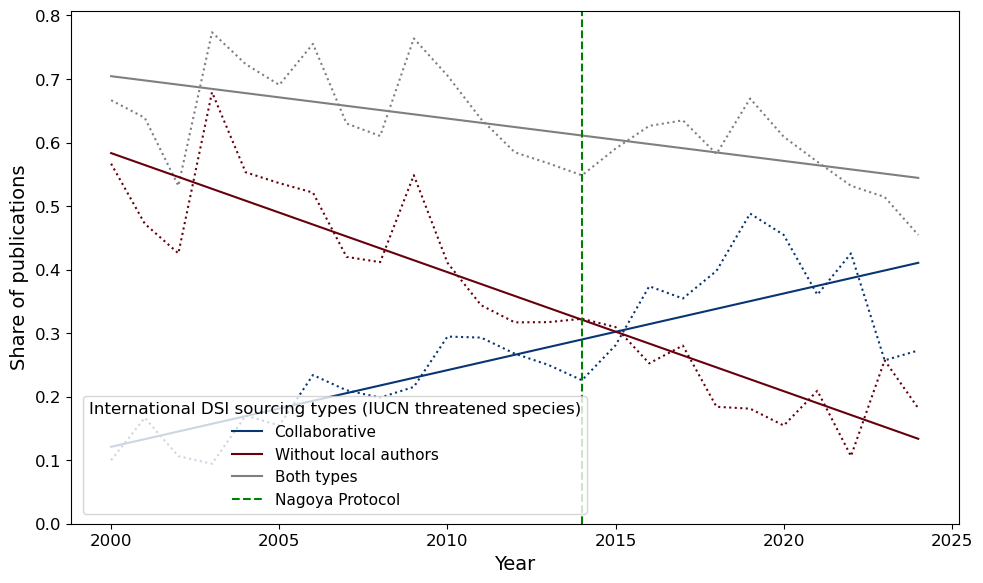

In [116]:
#define graph version
subtype = 'IUCN threatened species'

# Grouping and plotting the data
df_vis_timeline_spec= df_vis[['Publication year', 'International DSI sourcing', 'International DSI sourcing: At least one local lead author', 
        'International DSI sourcing: Foreign lead authors', 'International DSI sourcing: Without local authors']][(df_vis['Publication year'] >= 2000) & (df_vis[subtype] == 1)].fillna(0).groupby('Publication year').mean().rename(columns = dep_var_vis_dict)

#sum up different types of collaboration
df_vis_timeline_spec['Collaborative'] = df_vis_timeline_spec['At least one local lead author'] + df_vis_timeline_spec['Foreign lead authors']   

df_vis_timeline_version = df_vis_timeline_spec[['Collaborative','Without local authors', 'Both types']]


# Plot the original data 
ax = df_vis_timeline_version.plot(
    figsize=(10, 6),
    color=[colors[col] for col in df_vis_timeline_version.columns]
)

# Apply linestyles & remove Extractivism and All connections from legend
for line, col in zip(ax.lines, df_vis_timeline_version.columns):
    line.set_linestyle(linestyles.get(col, ':'))
    line.set_label('_nolegend_')  # This removes them from the legend


# Fit and plot linear projections for Extractivism & All connections
for variable in df_vis_timeline_version.columns:
    x = df_vis_timeline_version.index.astype(int)  # Convert years to integers
    y = df_vis_timeline_version[variable].values

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    y_trend = slope * x + intercept  # Compute the fitted line

    # Plot the linear projection
    plt.plot(x, y_trend, linestyle='-', color=colors[variable], label=f'{variable}')
plt.rcParams.update({'font.size': 12})
# Add a vertical line at 2014 for the Nagoya Protocol entry into force
ax.axvline(x=2014, color='green', linestyle='--', label='Nagoya Protocol')

# Adding a legend and labels
plt.legend(loc='lower left', title="International DSI sourcing types (" + subtype + ")", fontsize = 11, bbox_to_anchor=(00.005, 0.005)) #, bbox_to_anchor=(0.7, 0.75)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Share of publications", fontsize = 14)
ax.set_ylim(0, None)

# Adjust layout
plt.tight_layout()
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".pdf")
plt.savefig(path+R"plots/timelines_international_dsi_sourcing_" + subtype + ".png")
# Show the plot
plt.show()


#### Follow-up analysis

In [121]:
df_vis.reset_index()[['Publication year', 'id_select']].groupby('Publication year').count()

,id_select
Publication year,
1953,1
1963,1
1968,1
1969,2
1970,2
1977,1
1978,1
1981,1
1983,2


In [123]:
df_vis_timeline

,Both types,At least one local lead author,Foreign lead authors,Without local authors,Collaborative
Publication year,,,,,
2000,0.389135,0.049889,0.087583,0.251663,0.137472
2001,0.370336,0.062500,0.081157,0.226679,0.143657
2002,0.356130,0.052544,0.082569,0.221018,0.135113
2003,0.354707,0.066849,0.085266,0.202592,0.152115
2004,0.361294,0.065789,0.084978,0.210526,0.150768
2005,0.348733,0.074407,0.073590,0.200736,0.147997
2006,0.352371,0.079382,0.088003,0.184986,0.167385
2007,0.342702,0.085915,0.085276,0.171511,0.171191
2008,0.333054,0.091492,0.084519,0.157043,0.176011


In [9]:
df.columns

Index(['extractivism_g77_oecd_1', 'extractivism_g77_brics_1',
       'extractivism_oecd_brics_1', 'extractivism_oecd_g77_1',
       'extractivism_brics_g77_1', 'extractivism_brics_oecd_1',
       'extractivism_g77_oecd_2', 'extractivism_g77_brics_2',
       'extractivism_oecd_brics_2', 'extractivism_oecd_g77_2',
       'extractivism_brics_g77_2', 'extractivism_brics_oecd_2', 'g77_oecd',
       'g77_brics', 'oecd_brics', 'oecd_g77', 'brics_g77', 'brics_oecd',
       'other_g77_oecd', 'other_g77_brics', 'other_oecd_brics',
       'other_oecd_g77', 'other_brics_g77', 'other_brics_oecd', 'eukaryota',
       'bacteria', 'archaea', 'viruses', 'marine', 'pathogens', 'crops',
       'year_published', 'after_nagoya', 'megadiv', 'megadiv_g77',
       'megadiv_brics', 'iucn_threatened', 'public_health', 'biotechnology',
       'basic_research', 'foreign_lead', 'no_local_authors',
       'sourcing_international', 'local_lead', 'sourcing_domestic'],
      dtype='object')

In [11]:
df_regr = df[['g77_oecd',
       'g77_brics', 'oecd_brics', 'oecd_g77', 'brics_g77', 'brics_oecd',
       'other_g77_oecd', 'other_g77_brics', 'other_oecd_brics',
       'other_oecd_g77', 'other_brics_g77', 'other_brics_oecd','eukaryota',
       'bacteria', 'archaea', 'viruses', 'marine', 'pathogens','megadiv', 'megadiv_g77',
       'megadiv_brics','iucn_threatened', 'public_health', 'biotechnology',
       'basic_research', 'foreign_lead', 'no_local_authors',
       'sourcing_international', 'local_lead', 'sourcing_domestic', 'year_published']]


In [13]:
df_regr.to_csv(path+R"processed_data/regression_new.csv")